In [ ]:
import os

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile

zip_path = "/content/drive/MyDrive/indianDataset/indiandataset.zip"
extract_path = "/content/indiandatset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset unzipped successfully!")

Dataset unzipped successfully!


In [ ]:
print(os.listdir(os.path.join(extract_path, 'Indian-Traffic Sign-Dataset')))

['Images', 'traffic_sign.csv']


In [ ]:
import pandas as pd
import os

# Load CSV file
df = pd.read_csv(os.path.join(extract_path, 'Indian-Traffic Sign-Dataset', 'traffic_sign.csv'))

# Show first 5 rows
df.head()

,ClassId,Name
0,0,Give way
1,1,No entry
2,2,One-way traffic
3,3,One-way traffic
4,4,No vehicles in both directions


In [ ]:
print(df.columns)

print("Total Classes:", len(df))

Index(['ClassId', 'Name'], dtype='object')
Total Classes: 59


In [ ]:
# Core libraries
import os
import numpy as np
import pandas as pd
import random
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# Scikit-learn for data splitting and metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

# TensorFlow and Keras for deep learning
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model,Sequential
from tensorflow.keras.layers import (Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout,
                                     BatchNormalization, Activation, GlobalAveragePooling2D)
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau,ModelCheckpoint

Image Shape: (32, 32, 3)


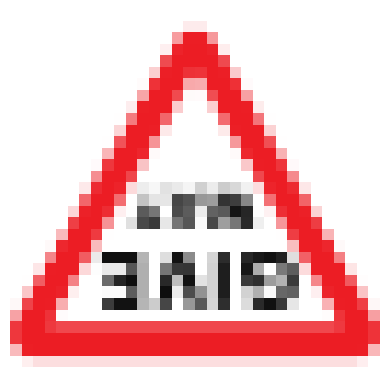

In [ ]:
# Get the ClassId for the first entry in the DataFrame
class_id = df.iloc[0]['ClassId']

# Construct the path to the directory containing images for this ClassId
# Assuming images are in /content/indiandatset/Indian-Traffic Sign-Dataset/Images/<ClassId>/
# and we'll pick the first image found in that directory.
images_base_dir = os.path.join(extract_path, 'Indian-Traffic Sign-Dataset', 'Images')
class_images_dir = os.path.join(images_base_dir, str(class_id))

# Get a list of files in the class directory
image_files = os.listdir(class_images_dir)

if image_files:
    # Pick the first image file
    first_image_file = image_files[0]
    img_path = os.path.join(class_images_dir, first_image_file)

    img = cv2.imread(img_path)

    # Check if the image was loaded successfully
    if img is not None:
        print("Image Shape:", img.shape)
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.axis("off")
        plt.show()
    else:
        print(f"Error: Could not load image from {img_path}")
elif os.path.exists(class_images_dir):
    print(f"Error: No images found in directory {class_images_dir}")
else:
    print(f"Error: Class directory not found: {class_images_dir}")

In [ ]:
#Load and Preprocess ALL Images

#Create Empty Lists
X = []
y = []

#Load the images
IMG_SIZE = 64
images_base_dir = os.path.join(extract_path, 'Indian-Traffic Sign-Dataset', 'Images')
for class_folder in os.listdir(images_base_dir):
    class_path = os.path.join(images_base_dir, class_folder)
    # Skip non-folder files
    if not os.path.isdir(class_path):
        continue
    for img_file in os.listdir(class_path):
        img_path = os.path.join(class_path, img_file)
        # Read image
        img = cv2.imread(img_path)
        # Skip broken images
        if img is None:
            continue
        # Resize image
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        # Convert BGR to RGB
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        # Store image
        X.append(img)
        # Store label
        y.append(int(class_folder))

#covert list to array
X = np.array(X)
y = np.array(y)

print("Total Images Shape:", X.shape)
print("Total Labels Shape:", y.shape)

Total Images Shape: (13971, 64, 64, 3)
Total Labels Shape: (13971,)


In [ ]:
# Noramalization and Augmentation

X = X / 255.0

datagen = ImageDataGenerator(

    rotation_range=15,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    fill_mode='nearest'
)

In [ ]:
#Train , validation and test Split
X_train, X_temp, y_train, y_temp = train_test_split(  X,y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(y_train,y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training Set :", X_train.shape)
print("Validation Set :", X_val.shape)
print("Testing Set :", X_test.shape)
print('-----------------------------')
print("Training Labels :", y_train.shape)
print("Validation Labels :", y_val.shape)
print("Testing Labels :", y_test.shape)

Training Set : (9779, 64, 64, 3)
Validation Set : (2096, 64, 64, 3)
Testing Set : (2096, 64, 64, 3)
-----------------------------
Training Labels : (9779,)
Validation Labels : (2096,)
Testing Labels : (2096,)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    Dropout,
    Flatten,
    Dense
)
from tensorflow.keras.optimizers import Adam

model = Sequential([

    Conv2D(32,(3,3),activation='relu',
           input_shape=(64,64,3)),
    BatchNormalization(),
    Conv2D(32,(3,3),activation='relu'),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Conv2D(64,(3,3),activation='relu'),
    BatchNormalization(),
    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Conv2D(128,(3,3),activation='relu'),
    BatchNormalization(),
    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Flatten(),

    Dense(512,activation='relu'),
    Dropout(0.5),

    Dense(59,activation='softmax')   # 59 classes
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 62, 62, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 60, 60, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 26, 26, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 11, 11, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 11, 11, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 9, 9, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 59)             │        30,267 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,367,259 (5.22 MB)

 Trainable params: 1,366,811 (5.21 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

checkpoint = ModelCheckpoint(
    "best_model.h5",
    monitor='val_accuracy',
    save_best_only=True,
    mode='max'
)

In [ ]:
X_train, X_val, X_test
y_train, y_val, y_test

(array([ 1, 20, 52, ..., 44, 54, 55]),
 array([56, 37, 21, ..., 20, 55, 23]),
 array([53, 45, 17, ..., 48, 42, 32]))

In [ ]:
print(X_train.shape)
print(y_train.shape)

(9779, 64, 64, 3)
(9779,)


In [ ]:
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(y_train, 59)
y_val = to_categorical(y_val, 59)
y_test = to_categorical(y_test, 59)

print(y_train.shape)
print(y_val.shape)
print(y_test.shape)

(9779, 59)
(2096, 59)
(2096, 59)


In [ ]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    validation_data=(X_val, y_val),
    epochs=20,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

Epoch 1/20
306/306 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.0891 - loss: 4.0906

306/306 ━━━━━━━━━━━━━━━━━━━━ 39s 88ms/step - accuracy: 0.1353 - loss: 3.5814 - val_accuracy: 0.0320 - val_loss: 5.9298 - learning_rate: 0.0010
Epoch 2/20
306/306 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.2264 - loss: 2.8937

306/306 ━━━━━━━━━━━━━━━━━━━━ 16s 54ms/step - accuracy: 0.2553 - loss: 2.7094 - val_accuracy: 0.4418 - val_loss: 1.8351 - learning_rate: 0.0010
Epoch 3/20
305/306 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.3308 - loss: 2.2679

306/306 ━━━━━━━━━━━━━━━━━━━━ 17s 56ms/step - accuracy: 0.3542 - loss: 2.1753 - val_accuracy: 0.5797 - val_loss: 1.3291 - learning_rate: 0.0010
Epoch 4/20
305/306 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.4239 - loss: 1.9111

306/306 ━━━━━━━━━━━━━━━━━━━━ 16s 52ms/step - accuracy: 0.4408 - loss: 1.8393 - val_accuracy: 0.6679 - val_loss: 1.0115 - learning_rate: 0.0010
Epoch 5/20
306/306 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.4954 - loss: 1.6235

...

306/306 ━━━━━━━━━━━━━━━━━━━━ 16s 52ms/step - accuracy: 0.7236 - loss: 0.8408 - val_accuracy: 0.8397 - val_loss: 0.4473 - learning_rate: 0.0010
Epoch 12/20
306/306 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.7471 - loss: 0.7811

306/306 ━━━━━━━━━━━━━━━━━━━━ 16s 54ms/step - accuracy: 0.7472 - loss: 0.7739 - val_accuracy: 0.8535 - val_loss: 0.4077 - learning_rate: 0.0010
Epoch 13/20
306/306 ━━━━━━━━━━━━━━━━━━━━ 17s 55ms/step - accuracy: 0.7611 - loss: 0.7235 - val_accuracy: 0.8488 - val_loss: 0.4141 - learning_rate: 0.0010
Epoch 14/20
306/306 ━━━━━━━━━━━━━━━━━━━━ 16s 53ms/step - accuracy: 0.7661 - loss: 0.6932 - val_accuracy: 0.8421 - val_loss: 0.4315 - learning_rate: 0.0010
Epoch 15/20
306/306 ━━━━━━━━━━━━━━━━━━━━ 16s 52ms/step - accuracy: 0.7856 - loss: 0.6388 - val_accuracy: 0.8511 - val_loss: 0.4210 - learning_rate: 0.0010
Epoch 16/20
305/306 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.7980 - loss: 0.5624

306/306 ━━━━━━━━━━━━━━━━━━━━ 16s 53ms/step - accuracy: 0.8022 - loss: 0.5596 - val_accuracy: 0.8750 - val_loss: 0.3102 - learning_rate: 5.0000e-04
Epoch 17/20
306/306 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.8244 - loss: 0.4979

306/306 ━━━━━━━━━━━━━━━━━━━━ 16s 53ms/step - accuracy: 0.8175 - loss: 0.5185 - val_accuracy: 0.8769 - val_loss: 0.3000 - learning_rate: 5.0000e-04
Epoch 18/20
306/306 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.8247 - loss: 0.4800

306/306 ━━━━━━━━━━━━━━━━━━━━ 16s 53ms/step - accuracy: 0.8250 - loss: 0.4824 - val_accuracy: 0.8798 - val_loss: 0.3008 - learning_rate: 5.0000e-04
Epoch 19/20
306/306 ━━━━━━━━━━━━━━━━━━━━ 16s 52ms/step - accuracy: 0.8314 - loss: 0.4661 - val_accuracy: 0.8306 - val_loss: 0.4473 - learning_rate: 5.0000e-04
Epoch 20/20
306/306 ━━━━━━━━━━━━━━━━━━━━ 16s 53ms/step - accuracy: 0.8358 - loss: 0.4566 - val_accuracy: 0.8764 - val_loss: 0.2991 - learning_rate: 5.0000e-04


In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8845 - loss: 0.2932
Test Accuracy: 0.8845419883728027
Test Loss: 0.29321661591529846


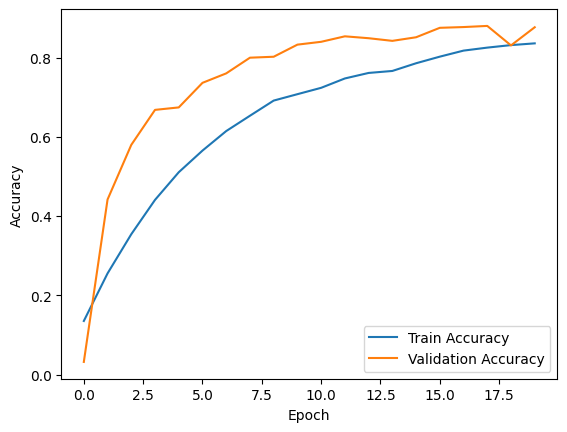

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
#test evaluation
test_loss, test_acc = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8845 - loss: 0.2932
Test Accuracy: 0.8845419883728027
Test Loss: 0.29321661591529846


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

print(classification_report(y_true, y_pred))

66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        30
           1       0.94      0.97      0.95        30
           2       0.51      0.67      0.58        30
           3       0.39      0.30      0.34        30
           4       1.00      0.83      0.91        30
           5       1.00      0.90      0.95        48
           6       0.97      1.00      0.98        30
           7       1.00      0.90      0.95        30
           8       1.00      0.99      0.99        90
           9       1.00      0.97      0.98        31
          10       0.97      0.93      0.95        30
          11       1.00      0.93      0.97        30
          12       0.97      0.97      0.97        30
          13       0.97      0.97      0.97        30
          14       1.00      0.93      0.97        30
          15       1.00      0.90      0.95        30
          16       1.00      0.97      0.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


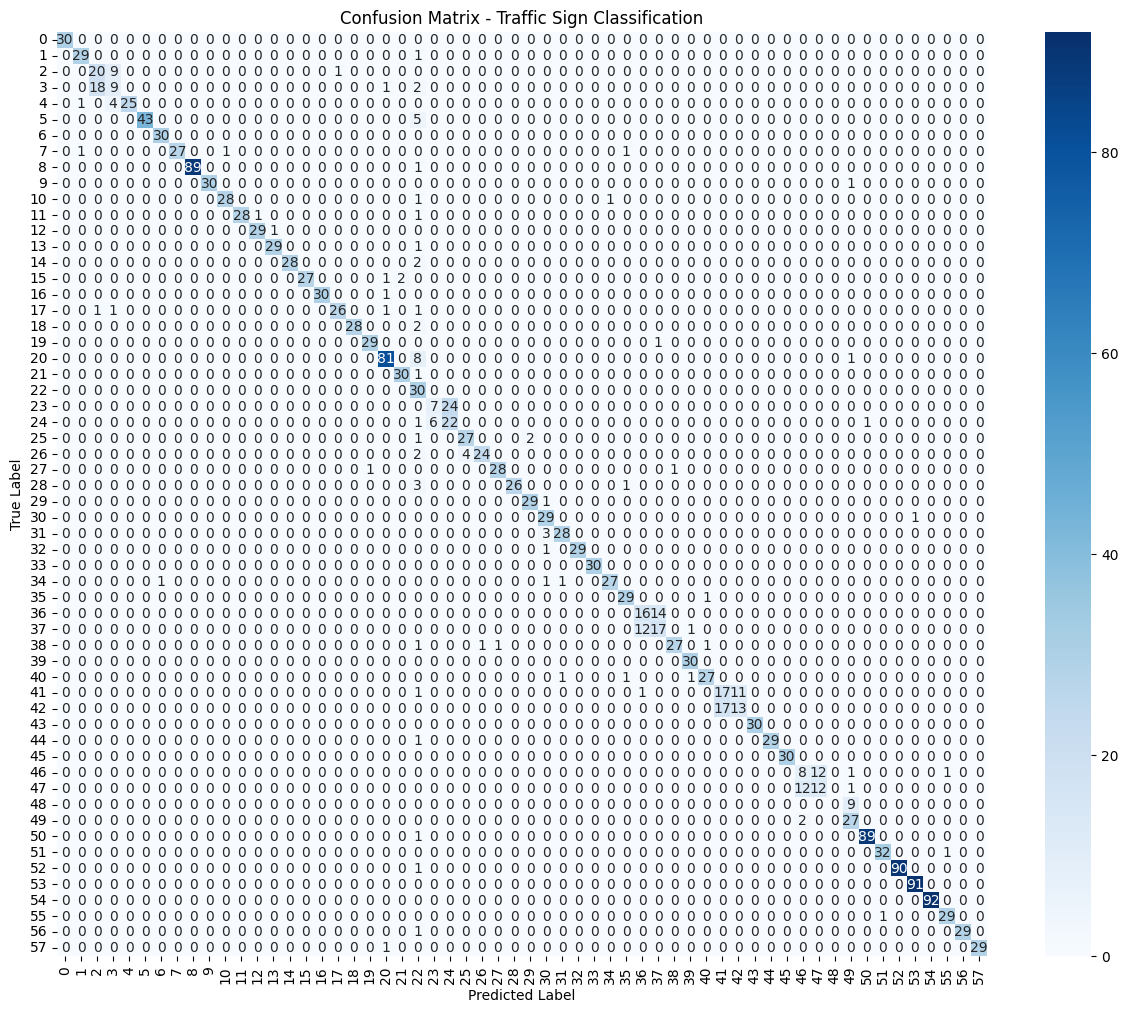

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Predictions
y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)

# True labels
y_true = np.argmax(y_test, axis=1)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot
plt.figure(figsize=(15,12))
sns.heatmap(cm,
    cmap='Blues',
    annot=True,
    fmt='d'
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Traffic Sign Classification")

plt.show()